### KNEIGHBORS CLASSIFIER MODELING

The following **KNeighbors Classifier models** are prepared:

_Model K1_     
A simple model is first built.

_Model K2_   
_Synthetic Minority Oversampling Technique for Nominal and Continuous features (SMOTE-NC)_ addresses the class imbalance. The model parameters are optimized.

_Model K3_    
Feature selection uses SelectKBest.

_Model K4_    
Feature selection uses Random Forest Classifier.

The following **metrics** are determined:    
_AUC_      
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_       
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners _(recall)_ is more expensive than false alarms _(precision)_.  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance particularly addressing overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection of encoded features reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [142]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [143]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [144]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [145]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

**Build a simple model**    
**Model K1** is a simple K-Neighbors Classifier model.

In [146]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [147]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


In [148]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [149]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [150]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


In [151]:
# Preprocessing to prepare categorical features encoding and numerical features scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[
                ['Monthly','Quarterly','Yearly'],         # contract_type
                ['Unsatisfied','Neutral','Satisfied']     # survey_response
            ],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols),
        ('nom', OneHotEncoder(
            drop=None,
            handle_unknown='ignore'
        ), nominal_cols),
    ],
    remainder=StandardScaler()
)

In [152]:
# Build a simple K-NeighborsClassifier model
knn_pipe1 = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])
knn_pipe1.fit(X_train, y_train)
knn_pipe1

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('knn', KNeighborsClassifier())])

In [153]:
# Accuracy of model on train and test data
knn_pipe1_acc_train = knn_pipe1.score(X_train, y_train)
knn_pipe1_acc_test = knn_pipe1.score(X_test, y_test)

print(f'The train accuracy of the model is {knn_pipe1_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {knn_pipe1_acc_test*100:.2f}%')

The train accuracy of the model is 91.04%
The test accuracy of the model is 89.99%


In [154]:
# Generate classification report K1
y_pred_K1 = knn_pipe1.predict(X_test)

print(classification_report(y_test, y_pred_K1))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1439
           1       0.08      0.01      0.01       149

    accuracy                           0.90      1588
   macro avg       0.49      0.50      0.48      1588
weighted avg       0.83      0.90      0.86      1588



The simple K-Neighbors Classifier mode (**Model K1**) does not catch churners effectively (Recall = 0.01) as shown in the classification report K1. This will be addressed by using a technique to balance the class imbalance.
   
**Synthetic Minority Oversampling Technique for Nominal and Continuous features (SMOTE-NC)**     
In order to address the class imbalance, SMOTE-NC is used and then the model is optimized. The model is called **Model K2**.    

**SMOTE-NC** is a technique that tries to overcome the imbalanced dataset machine learning bias towards the majority class by creating entirely new and synthetic samples which are similar to the samples that are already in the train dataset.

In [155]:
# Define ordinal mapping
ord_mapping = [['Monthly','Quarterly','Yearly'],['Unsatisfied','Neutral','Satisfied']]

In [156]:
# Verify ordinal and nominal columns

print(f'Ordinal columns: {ordinal_cols}')
print(f'Nominal columns: {nominal_cols}')

Ordinal columns: ['contract_type', 'survey_response']
Nominal columns: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type']


In [157]:
# Prepare data for SMOTE-NC
preprocessor = ColumnTransformer(transformers=[
    ('ord', Pipeline([
        ('enc', OrdinalEncoder(categories=ord_mapping)),
        ('scaler', StandardScaler())
    ]), ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('num', StandardScaler(), numeric_cols)
])

In [158]:
# Prepare SMOTE-NC
cat_indices = list(range(0,11))
smote_step = SMOTENC(categorical_features=cat_indices, random_state=42)

In [159]:
# Assemble the pipeline
from imblearn.pipeline import Pipeline

knn_pipe2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_step),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
knn_pipe2.fit(X_train, y_train)
knn_pipe2

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [160]:
# Accuracy of model on train and test data
knn_pipe2_acc_train = knn_pipe2.score(X_train, y_train)
knn_pipe2_acc_test = knn_pipe2.score(X_test, y_test)

print(f'The train accuracy of the model is {knn_pipe2_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {knn_pipe2_acc_test*100:.2f}%')

The train accuracy of the model is 100.00%
The test accuracy of the model is 46.47%


The model is **overfitting** and will be improved.

In [161]:
# Set up parameter grid
param_grid_knn = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [162]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(
    estimator=knn_pipe2,
    param_grid=param_grid_knn,
    cv=cv,
    n_jobs=-1,
    scoring='roc_auc',
    error_score='raise'
)
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ord',
                                                                         Pipeline(steps=[('enc',
                                                                                          OrdinalEncoder(categories=[['Monthly',
                                                                                                                      'Quarterly',
                                                                                                                      'Yearly'],
                                                                                                                     ['Unsatisfied',
                                                                                                                      'Neutral',
                                                                                                                      'Satisfied']])),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['contract_type',
                                                                          'surv...
                                                                          'marketing_click_rate',
                                                                          'nps_score',
                                                                          'referral_count',
                                                                          'tenure_fee_interaction'])])),
                                       ('smote',
                                        SMOTENC(categorical_features=[0, 1, 2,
                                                                      3, 4, 5,
                                                                      6, 7, 8,
                                                                      9, 10],
                                                random_state=42)),
                                       ('knn',
                                        KNeighborsClassifier(weights='distance'))]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [40, 50, 60, 70, 80],
                         'knn__weights': ['uniform']},
             scoring='roc_auc')

In [163]:
# Verify the best parameters

print(f'Best parameters: {grid_knn.best_params_}')
print(f'Best score: {grid_knn.best_score_:.4f}')

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 80, 'knn__weights': 'uniform'}
Best score: 0.6942


In [164]:
# Access the optimized model
knn_pipe2_opt = grid_knn.best_estimator_
knn_pipe2_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=80))])

In [165]:
# Accuracy on train and test data
knn_pipe2_opt_acc_train = knn_pipe2_opt.score(X_train, y_train)
knn_pipe2_opt_acc_test = knn_pipe2_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {knn_pipe2_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {knn_pipe2_opt_acc_test*100:.2f}%')

The train accuracy of the model is 57.98%
The test accuracy of the model is 53.65%


The model is **underfitting** and will be improved later using feature selection.

In [166]:
# Generate classification report K2
y_pred_K2 = knn_pipe2_opt.predict(X_test)

print(classification_report(y_test, y_pred_K2))

              precision    recall  f1-score   support

           0       0.96      0.51      0.67      1439
           1       0.14      0.78      0.24       149

    accuracy                           0.54      1588
   macro avg       0.55      0.64      0.45      1588
weighted avg       0.88      0.54      0.63      1588



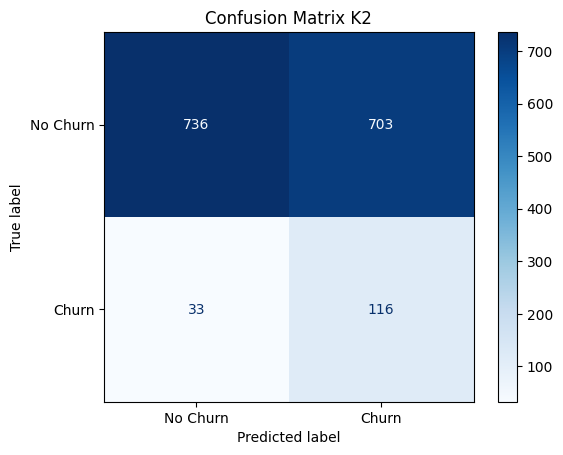

In [167]:
# Display confusion matrix K2
conf_matrix_K2 = confusion_matrix(y_test, y_pred_K2)
disp_K2 = ConfusionMatrixDisplay(conf_matrix_K2, display_labels=['No Churn','Churn'])
disp_K2.plot(cmap='Blues')
plt.title('Confusion Matrix K2')
plt.show()

In [168]:
# Values for false positive (fp_K2), false negative (fn_K2), true positive (tp_K2) and true negative (tn_K2)
fp_K2 = conf_matrix_K2[0][1]
fn_K2 = conf_matrix_K2[1][0]
tp_K2 = conf_matrix_K2[1][1]
tn_K2 = conf_matrix_K2[0][0]

print(f' fp_K2: {fp_K2} \n fn_K2: {fn_K2} \n tp_K2: {tp_K2} \n tn_K2: {tn_K2}')

 fp_K2: 703 
 fn_K2: 33 
 tp_K2: 116 
 tn_K2: 736


In [169]:
# Calculations for accuracy, precision, recall
accuracy_K2 = (tp_K2 + tn_K2)/len(y_test)
precision_K2 = tp_K2/(tp_K2 + fp_K2)
recall_K2 = tp_K2/(tp_K2 + fn_K2)

print(f'Accuracy_K2: {accuracy_K2:.2f}')
print(f'Precision_K2: {precision_K2:.2f}')
print(f'Recall_K2: {recall_K2:.2f}')
print(f'-'*18)

Accuracy_K2: 0.54
Precision_K2: 0.14
Recall_K2: 0.78
------------------


In [170]:
# Calculate F2 score for Model K2
beta = 2
F2_score_K2 = (1 + beta**2) * (precision_K2 * recall_K2) / (beta**2 * precision_K2 + recall_K2)

print(f'The F2 score for Model K2 is {F2_score_K2:.4f}')

The F2 score for Model K2 is 0.4099


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [171]:
# Profit/loss analysis for Model K2
L=500
C=40
Profit_Loss_K2 = tp_K2*(L - C) - fp_K2*C - fn_K2*L

print(f'The profit or loss is ${Profit_Loss_K2}')

The profit or loss is $8740


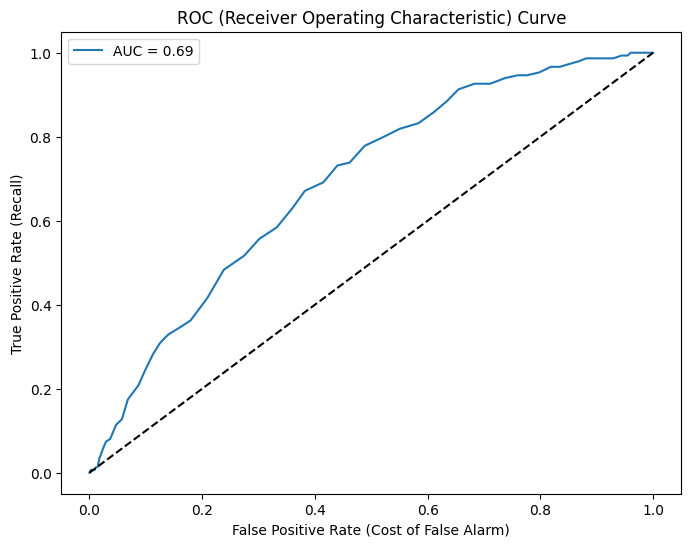

In [172]:
# Plot the ROC Curve
y_probs_K2 = knn_pipe2_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_K2)
auc_K2 = round(roc_auc_score(y_test, y_probs_K2), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_K2):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [173]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_K1 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_K1 :.1f}')

The optimal threshold is 0.5


In [174]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_K2)
avg_precision = average_precision_score(y_test, y_probs_K2)

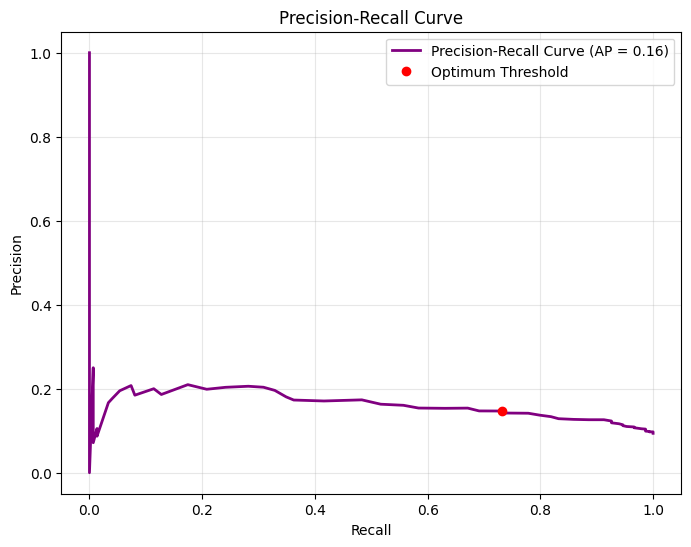

In [175]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_K1))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimum Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [176]:
# Evaluate precision and recall at different thresholds
y_probs_K2 = knn_pipe2_opt.predict_proba(X_test)[:, 1]
thresholds = np.arange(0, 0.7, 0.05)
for threshold in thresholds:
    preds = (y_probs_K2 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.09 | Recall=1.00
Threshold=0.15 | Precision=0.09 | Recall=1.00
Threshold=0.20 | Precision=0.10 | Recall=1.00
Threshold=0.25 | Precision=0.10 | Recall=0.99
Threshold=0.30 | Precision=0.10 | Recall=0.98
Threshold=0.35 | Precision=0.11 | Recall=0.95
Threshold=0.40 | Precision=0.12 | Recall=0.94
Threshold=0.45 | Precision=0.13 | Recall=0.89
Threshold=0.50 | Precision=0.14 | Recall=0.80
Threshold=0.55 | Precision=0.15 | Recall=0.69
Threshold=0.60 | Precision=0.16 | Recall=0.52
Threshold=0.65 | Precision=0.17 | Recall=0.36


In [177]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_K2 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.4


**Model K2** uses the threshold maximizing profits

In [178]:
# Define the Model K2 threshold
threshold_K2 = best_threshold

In [179]:
# Use the threshold maximizing profits
y_pred_K2 = (y_probs_K2 >= best_threshold).astype(int)

In [180]:
# Generate classification report K2

print(classification_report(y_test, y_pred_K2))

              precision    recall  f1-score   support

           0       0.98      0.26      0.41      1439
           1       0.12      0.94      0.21       149

    accuracy                           0.33      1588
   macro avg       0.55      0.60      0.31      1588
weighted avg       0.90      0.33      0.39      1588



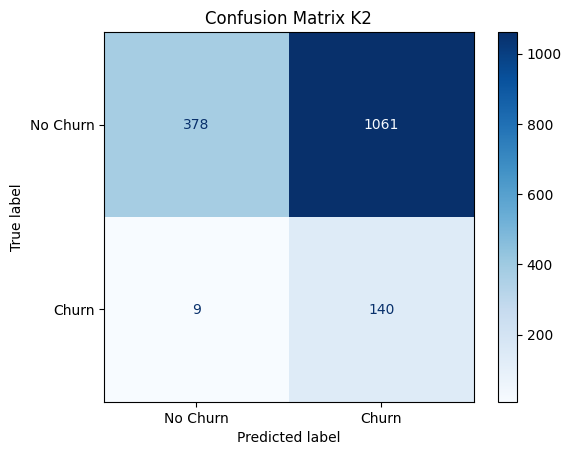

In [181]:
# Display confusion matrix K2
conf_matrix_K2 = confusion_matrix(y_test, y_pred_K2)
disp_K2 = ConfusionMatrixDisplay(conf_matrix_K2, display_labels=['No Churn','Churn'])
disp_K2.plot(cmap='Blues')
plt.title('Confusion Matrix K2')
plt.show()

In [182]:
# Values for false positive (fp_K2), false negative (fn_K2), true positive (tp_K2) and true negative (tn_K2)
fp_K2 = conf_matrix_K2[0][1]
fn_K2 = conf_matrix_K2[1][0]
tp_K2 = conf_matrix_K2[1][1]
tn_K2 = conf_matrix_K2[0][0]

print(f' fp_K2: {fp_K2} \n fn_K2: {fn_K2} \n tp_K2: {tp_K2} \n tn_K2: {tn_K2}')

 fp_K2: 1061 
 fn_K2: 9 
 tp_K2: 140 
 tn_K2: 378


In [183]:
# Calculations for accuracy, precision, recall
accuracy_K2 = (tp_K2 + tn_K2)/len(y_test)
precision_K2 = tp_K2/(tp_K2 + fp_K2)
recall_K2 = tp_K2/(tp_K2 + fn_K2)

print(f'Accuracy_K2: {accuracy_K2:.2f}')
print(f'Precision_K2: {precision_K2:.2f}')
print(f'Recall_K2: {recall_K2:.2f}')
print(f'-'*18)

Accuracy_K2: 0.33
Precision_K2: 0.12
Recall_K2: 0.94
------------------


In [184]:
# Calculate F2 score for Model K2
beta = 2
F2_score_K2 = (1 + beta**2) * (precision_K2 * recall_K2) / (beta**2 * precision_K2 + recall_K2)

print(f'The F2 score for Model K2 is {F2_score_K2:.4f}')

The F2 score for Model K2 is 0.3895


In [185]:
# Profit/loss analysis for Model K2
Profit_Loss_K2 = tp_K2*(L - C) - fp_K2*C - fn_K2*L

print(f'The profit or loss is ${Profit_Loss_K2}')

The profit or loss is $17460


**Feature Importance Model K2**      
The model finds the features **payment_failures**, **csat_score**, and **marketing_click_rate**, to be highly important.

Feature importance in KNN is inferred using permutation importance where one feature is shuffled randomly at a time. The change in model performance is then measured - the drop in performance, for example, is inferred as the magnitude of feature importance.

**payment_failures**  has the largest drop in performance and is, therefore, the most important feature - this is sometimes known as involuntary churn; if a card expires or a bank rejects a payment, some customers don't bother to update their info - they just let the account die   

**csat_score**  customers who leave don't leave randomly but because they are unhappy; unhappiness precedes churn     

**marketing_click_rate**  customer engagement is a churn indicator  


In [186]:
# Use permutation importance
result = permutation_importance(
    knn_pipe2,
    X_test,
    y_test,
    n_repeats=20,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [187]:
# Interpret the results
K2_feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

K2_feature_importance_df.head(20)

,feature,importance_mean
16,payment_failures,0.016798
22,csat_score,0.007075
25,marketing_click_rate,0.003876
15,payment_method,0.002539
17,discount_applied,0.001318
29,tenure_fee_interaction,0.000262
27,survey_response,-0.000264
6,signup_channel,-0.000434
12,usage_growth_rate,-0.001440
1,age,-0.001463


In [188]:
# Select the first twenty features
K2_feature_importance_df = K2_feature_importance_df.iloc[:20]

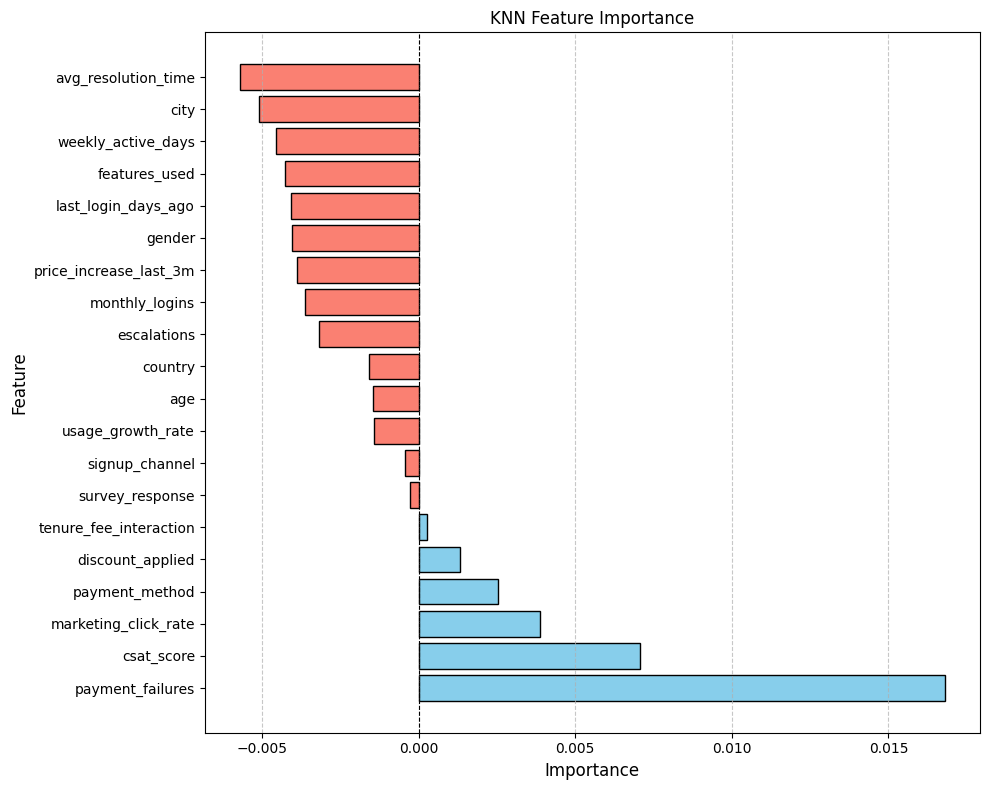

In [189]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in K2_feature_importance_df['importance_mean']]
plt.barh(K2_feature_importance_df['feature'], K2_feature_importance_df['importance_mean'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('KNN Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**     
**Model K3** uses SelectKBest to select the best number of top features.

In [190]:
# Obtain the best number of features based on AUC
from imblearn.pipeline import Pipeline

auc=[]
features = np.arange(18, 24, 2)
for i in features:
  # Set up selector
  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build the pipeline
  knn_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('smote', smote_step),
      ('feature_selection', selector),
      ('knn', KNeighborsClassifier())
  ])
  knn_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'knn__n_neighbors': [40, 50, 60, 70, 80],
      'knn__weights': ['uniform'],
      'knn__metric': ['euclidean', 'manhattan']
  }
  # Run RandomizedSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_knn = GridSearchCV(knn_pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
  grid_knn.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_knn_opt = grid_knn.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_knn_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 18 | AUC = 0.7110
Number of Features = 20 | AUC = 0.7412
Number of Features = 22 | AUC = 0.7307


In [191]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 20.


In [192]:
# Set up selector
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [193]:
# Assemble the full pipeline using SelectKBest to select the top features
knn_model_K3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_step),
    ('select', selector),
    ('knn', KNeighborsClassifier())
])
knn_model_K3.fit(X_train, y_train)
knn_model_K3

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('select',
                 SelectKBest(k=np.int64(20),
                             score_func=<function mutual_info_classif at 0x7c09f6dc39c0>)),
                ('knn', KNeighborsClassifier())])

In [194]:
# Set up parameter grid
param_grid_K3 = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [195]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_grid_K3 = GridSearchCV(
    estimator=knn_model_K3,
    param_grid=param_grid_K3,
    cv=cv,
    n_jobs=-1,
    scoring='f1',
    error_score='raise'
)
knn_grid_K3.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ord',
                                                                         Pipeline(steps=[('enc',
                                                                                          OrdinalEncoder(categories=[['Monthly',
                                                                                                                      'Quarterly',
                                                                                                                      'Yearly'],
                                                                                                                     ['Unsatisfied',
                                                                                                                      'Neutral',
                                                                                                                      'Satisfied']])),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['contract_type',
                                                                          'surv...
                                                                          'tenure_fee_interaction'])])),
                                       ('smote',
                                        SMOTENC(categorical_features=[0, 1, 2,
                                                                      3, 4, 5,
                                                                      6, 7, 8,
                                                                      9, 10],
                                                random_state=42)),
                                       ('select',
                                        SelectKBest(k=np.int64(20),
                                                    score_func=<function mutual_info_classif at 0x7c09f6dc39c0>)),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [40, 50, 60, 70, 80],
                         'knn__weights': ['uniform']},
             scoring='f1')

In [196]:
# Verify the best parameters

print(f'Best parameters: {knn_grid_K3.best_params_}')
print(f'Best score: {knn_grid_K3.best_score_:.4f}')

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 80, 'knn__weights': 'uniform'}
Best score: 0.2885


In [197]:
# Access the optimized model
knn_grid_K3_opt = knn_grid_K3.best_estimator_
knn_grid_K3_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('select',
                 SelectKBest(k=np.int64(20),
                             score_func=<function mutual_info_classif at 0x7c09f6dc39c0>)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=80))])

In [198]:
# Accuracy on train and test data
knn_grid_K3_opt_acc_train = knn_grid_K3_opt.score(X_train, y_train)
knn_grid_K3_opt_acc_test = knn_grid_K3_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {knn_grid_K3_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {knn_grid_K3_opt_acc_test*100:.2f}%')

The train accuracy of the model is 73.00%
The test accuracy of the model is 69.52%


In [199]:
# Generate classification report
y_pred_K3 = knn_grid_K3_opt.predict(X_test)

print(classification_report(y_test, y_pred_K3))

              precision    recall  f1-score   support

           0       0.96      0.69      0.81      1439
           1       0.19      0.70      0.30       149

    accuracy                           0.70      1588
   macro avg       0.57      0.70      0.55      1588
weighted avg       0.89      0.70      0.76      1588



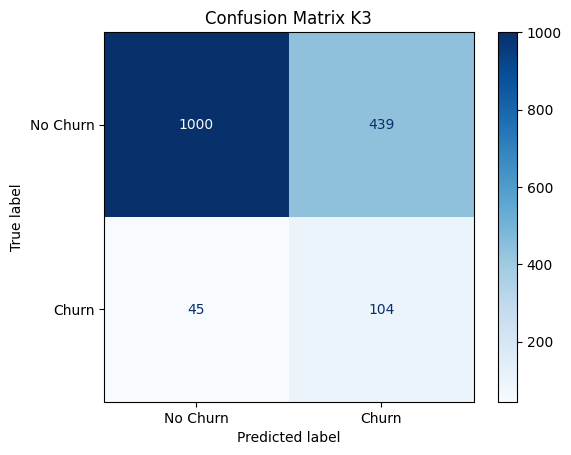

In [200]:
# Display confusion matrix
conf_matrix_K3 = confusion_matrix(y_test, y_pred_K3)
disp_K3 = ConfusionMatrixDisplay(conf_matrix_K3, display_labels=['No Churn','Churn'])
disp_K3.plot(cmap='Blues')
plt.title('Confusion Matrix K3')
plt.show()

In [201]:
# Values for false positive (fp_K3), false negative (fn_K3), true positive (tp_K3) and true negative (tn_K3)
fp_K3 = conf_matrix_K3[0][1]
fn_K3 = conf_matrix_K3[1][0]
tp_K3 = conf_matrix_K3[1][1]
tn_K3 = conf_matrix_K3[0][0]

print(f' fp_K3: {fp_K3} \n fn_K3: {fn_K3} \n tp_K3: {tp_K3} \n tn_K3: {tn_K3}')

 fp_K3: 439 
 fn_K3: 45 
 tp_K3: 104 
 tn_K3: 1000


In [202]:
# Calculations for accuracy, precision, recall
accuracy_K3 = (tp_K3 + tn_K3)/len(y_test)
precision_K3 = tp_K3/(tp_K3 + fp_K3)
recall_K3 = tp_K3/(tp_K3 + fn_K3)

print(f'Accuracy: {accuracy_K3:.2f}')
print(f'Precision: {precision_K3:.2f}')
print(f'Recall: {recall_K3:.2f}')
print(f'-'*15)

Accuracy: 0.70
Precision: 0.19
Recall: 0.70
---------------


In [203]:
# Calculate F2 score
beta = 2
F2_score_K3 = (1 + beta**2) * (precision_K3 * recall_K3) / (beta**2 * precision_K3 + recall_K3)

print(f'The F2 score is {F2_score_K3:.4f}')

The F2 score is 0.4565


In [204]:
# Profit/loss analysis
Profit_Loss_K3 = tp_K3*(L - C) - fp_K3*C - fn_K3*L

print(f'The profit or loss is ${Profit_Loss_K3}')

The profit or loss is $7780


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

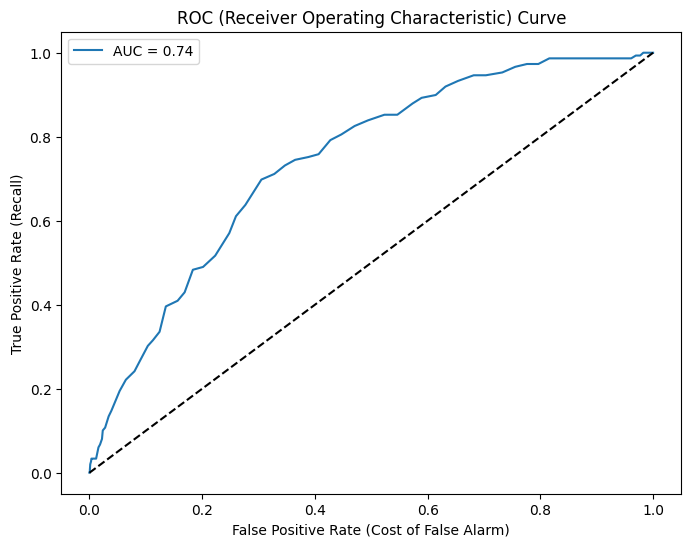

In [205]:
# Plot the ROC Curve
y_probs_K3 = knn_grid_K3_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_K3)
auc_K3 = round(roc_auc_score(y_test, y_probs_K3), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_K3):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [206]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_K3 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_K3 :.4f}')

The optimal threshold is 0.5125


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [207]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_K3)
avg_precision = average_precision_score(y_test, y_probs_K3)

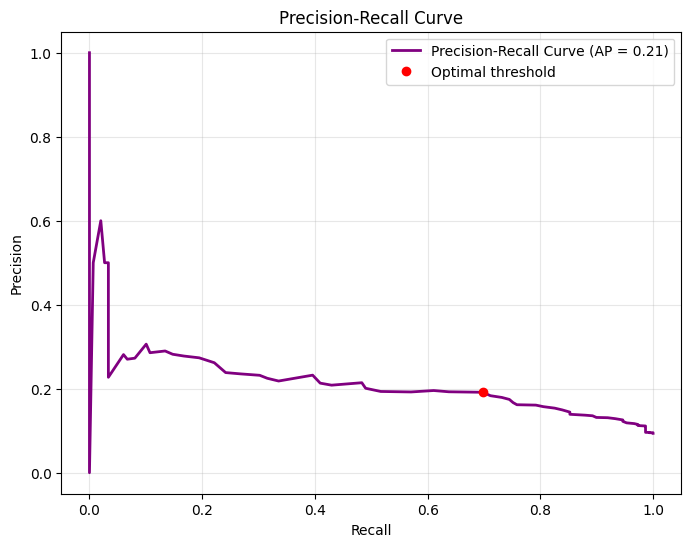

In [208]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_K3))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [209]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_K3 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.10 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=0.99
Threshold=0.15 | Precision=0.10 | Recall=0.99
Threshold=0.20 | Precision=0.11 | Recall=0.99
Threshold=0.25 | Precision=0.11 | Recall=0.97
Threshold=0.30 | Precision=0.13 | Recall=0.95
Threshold=0.35 | Precision=0.14 | Recall=0.88
Threshold=0.40 | Precision=0.15 | Recall=0.84
Threshold=0.45 | Precision=0.16 | Recall=0.76
Threshold=0.50 | Precision=0.18 | Recall=0.71
Threshold=0.55 | Precision=0.19 | Recall=0.57
Threshold=0.60 | Precision=0.21 | Recall=0.41
Threshold=0.65 | Precision=0.23 | Recall=0.30
Threshold=0.70 | Precision=0.27 | Recall=0.19
Threshold=0.75 | Precision=0.29 | Recall=0.11


In [210]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_K3 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3


In [211]:
# Define Model K3 threshold
threshold_K3 = best_threshold

In [212]:
# Use the threshold that maximizes profit
y_pred_K3 = (y_probs_K3 >= best_threshold).astype(int)

In [213]:
# Generate classification report

print(classification_report(y_test, y_pred_K3))

              precision    recall  f1-score   support

           0       0.98      0.32      0.48      1439
           1       0.13      0.95      0.22       149

    accuracy                           0.38      1588
   macro avg       0.55      0.63      0.35      1588
weighted avg       0.90      0.38      0.46      1588



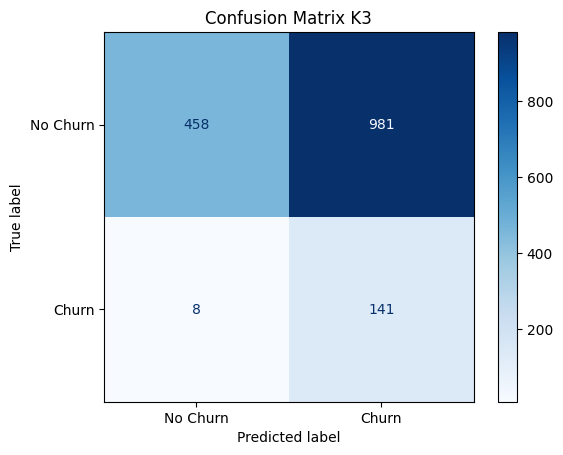

In [214]:
# Display confusion matrix
conf_matrix_K3 = confusion_matrix(y_test, y_pred_K3)
disp_K3 = ConfusionMatrixDisplay(conf_matrix_K3, display_labels=['No Churn','Churn'])
disp_K3.plot(cmap='Blues')
plt.title('Confusion Matrix K3')
plt.show()

In [215]:
# Values for false positive (fp_K3), false negative (fn_K3), true positive (tp_K3) and true negative (tn_K3)
fp_K3 = conf_matrix_K3[0][1]
fn_K3 = conf_matrix_K3[1][0]
tp_K3 = conf_matrix_K3[1][1]
tn_K3 = conf_matrix_K3[0][0]

print(f' fp_K3: {fp_K3} \n fn_K3: {fn_K3} \n tp_K3: {tp_K3} \n tn_K3: {tn_K3}')

 fp_K3: 981 
 fn_K3: 8 
 tp_K3: 141 
 tn_K3: 458


In [216]:
# Calculations for accuracy, precision, recall
accuracy_K3 = (tp_K3 + tn_K3)/len(y_test)
precision_K3 = tp_K3/(tp_K3 + fp_K3)
recall_K3 = tp_K3/(tp_K3 + fn_K3)

print(f'Accuracy: {accuracy_K3:.2f}')
print(f'Precision: {precision_K3:.2f}')
print(f'Recall: {recall_K3:.2f}')
print(f'-'*15)

Accuracy: 0.38
Precision: 0.13
Recall: 0.95
---------------


In [217]:
# Calculate F2 score
beta = 2
F2_score_K3 = (1 + beta**2) * (precision_K3 * recall_K3) / (beta**2 * precision_K3 + recall_K3)

print(f'The F2 score is {F2_score_K3:.4f}')

The F2 score is 0.4104


In [218]:
# Profit/loss analysis
Profit_Loss_K3 = tp_K3*(L - C) - fp_K3*C - fn_K3*L

print(f'The profit or loss is ${Profit_Loss_K3}')

The profit or loss is $21620


**Feature Importance Model K3**

The model finds the features **tenure_months**, **age**, **usage_growth_rate**, and **mail_open_rate** to be highly important.


In [219]:
# Get feature names after preprocessing
feature_names = knn_grid_K3_opt.named_steps["preprocessor"].get_feature_names_out()

In [220]:
# Access the selector
selector = knn_grid_K3_opt.named_steps["select"]

In [221]:
# Get scores and selected features
scores = selector.scores_
mask = selector.get_support()

In [222]:
# Extract scores of selected features
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names
selected_scores = scores[mask]

print(f'There are {len(selected_features)} selected features.')

There are 20 selected features.


In [223]:
# Match features to scores
K3_feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': selected_scores
}).sort_values(by='importance', ascending=False)

# Reset index
K3_feature_importance_df = K3_feature_importance_df.reset_index(drop=True)
K3_feature_importance_df.index = K3_feature_importance_df.index + 1
K3_feature_importance_df.index.name = "Rank"

K3_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.475408
2,age,0.472280
3,usage_growth_rate,0.466614
4,email_open_rate,0.466104
5,monthly_logins,0.463152
6,marketing_click_rate,0.458633
7,tenure_fee_interaction,0.445037
8,nps_score,0.444667
9,last_login_days_ago,0.432216


In [224]:
# Select the first twenty features
K3_feature_importance_df = K3_feature_importance_df.iloc[:20]

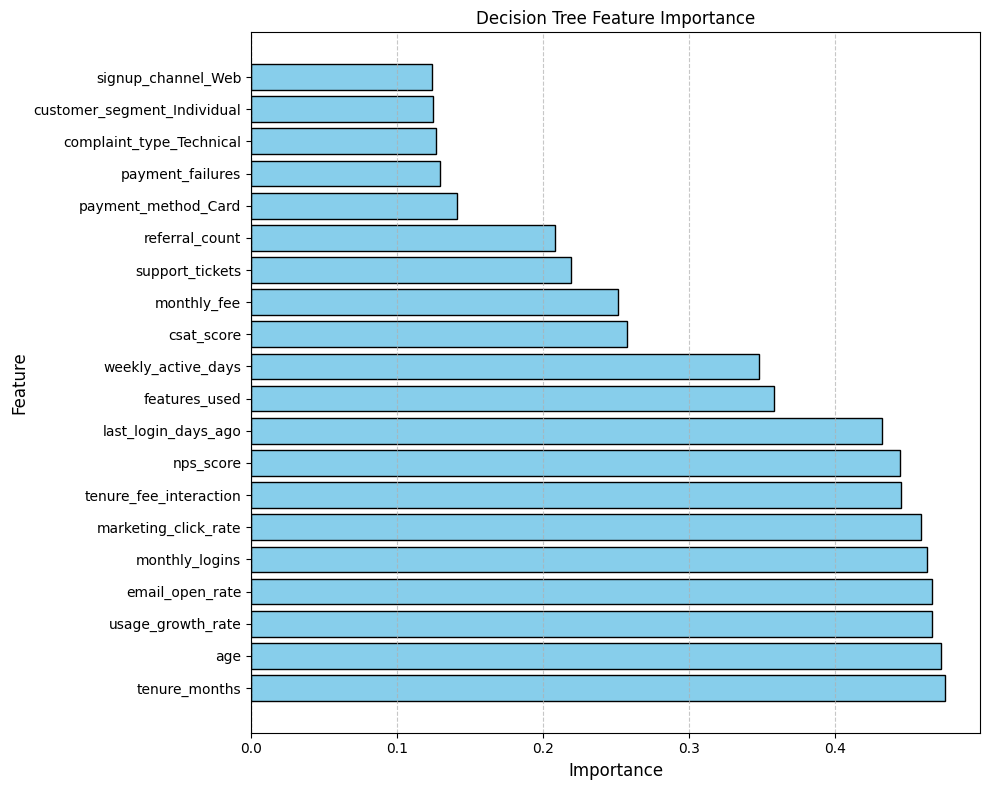

In [225]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['skyblue']
plt.barh(K3_feature_importance_df['feature'], K3_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model K4** uses Random Forest Classifier to select the best number of top features.

In [226]:
# Obtain the best number of features based on maximum AUC
from imblearn.pipeline import Pipeline

auc=[]
features = np.arange(18, 24, 2)
for i in features:
  # Build the pipeline
  knn_pipe = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('smote', smote_step),
      ('select', SelectFromModel(RandomForestClassifier(random_state=42), max_features=i,
          threshold=-float("inf"))),   # ensures exactly the number of features
      ('knn', KNeighborsClassifier())
  ])
  knn_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
  }
  # Run RandomizedSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_knn = RandomizedSearchCV(knn_pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
  grid_knn.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_knn_opt = grid_knn.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_knn_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 18 | AUC = 0.7703
Number of Features = 20 | AUC = 0.7595
Number of Features = 22 | AUC = 0.7548


In [227]:
# Extract the best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 18.


In [228]:
# Assemble the pipeline using best features
knn_pipe_K4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_step),
    ('select', SelectFromModel(RandomForestClassifier(random_state=42), max_features=best_features,
        threshold=-float("inf"))),
    ('knn', KNeighborsClassifier())
])
knn_pipe_K4.fit(X_train, y_train)
knn_pipe_K4

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('select',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(18), threshold=-inf)),
                ('knn', KNeighborsClassifier())])

In [281]:
# Set up parameter grid
param_grid_K4 = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [282]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_grid_K4 = GridSearchCV(
    estimator=knn_pipe_K4,
    param_grid=param_grid_K4,
    cv=cv,
    n_jobs=-1,
    scoring='f1',
    error_score='raise'
)
knn_grid_K4.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ord',
                                                                         Pipeline(steps=[('enc',
                                                                                          OrdinalEncoder(categories=[['Monthly',
                                                                                                                      'Quarterly',
                                                                                                                      'Yearly'],
                                                                                                                     ['Unsatisfied',
                                                                                                                      'Neutral',
                                                                                                                      'Satisfied']])),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['contract_type',
                                                                          'surv...
                                        SMOTENC(categorical_features=[0, 1, 2,
                                                                      3, 4, 5,
                                                                      6, 7, 8,
                                                                      9, 10],
                                                random_state=42)),
                                       ('select',
                                        SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                                        max_features=np.int64(18),
                                                        threshold=-inf)),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [40, 50, 60, 70, 80],
                         'knn__weights': ['uniform']},
             scoring='f1')

In [283]:
# Verify the best parameters

print(f'Best parameters: {knn_grid_K4.best_params_}')
print(f'Best score: {knn_grid_K4.best_score_:.4f}')

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 80, 'knn__weights': 'uniform'}
Best score: 0.3101


In [284]:
# Access the optimized model
knn_grid_K4_opt = knn_grid_K4.best_estimator_
knn_grid_K4_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segme...
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                               10],
                         random_state=42)),
                ('select',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(18), threshold=-inf)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=80))])

In [285]:
# Accuracy of model on train and test data
knn_grid_K4_opt_acc_train = knn_grid_K4_opt.score(X_train, y_train)
knn_grid_K4_opt_acc_test = knn_grid_K4_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {knn_grid_K4_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {knn_grid_K4_opt_acc_test*100:.2f}%')

The train accuracy of the model is 74.74%
The test accuracy of the model is 73.55%


In [286]:
# Generate classification report
y_pred_K4 = knn_grid_K4_opt.predict(X_test)

print(classification_report(y_test, y_pred_K4))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84      1439
           1       0.21      0.66      0.32       149

    accuracy                           0.74      1588
   macro avg       0.58      0.70      0.58      1588
weighted avg       0.89      0.74      0.79      1588



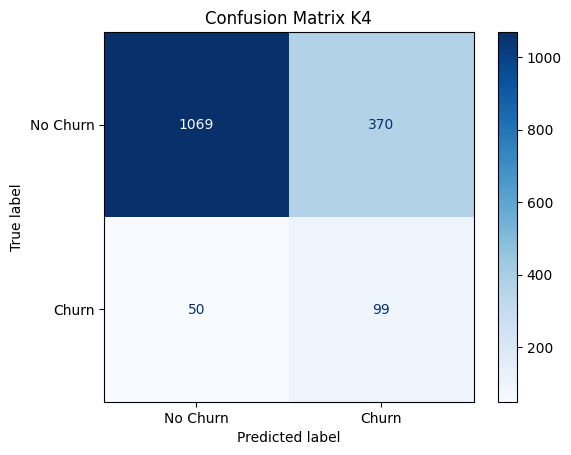

In [287]:
# Display confusion matrix
conf_matrix_K4 = confusion_matrix(y_test, y_pred_K4)
disp_K4 = ConfusionMatrixDisplay(conf_matrix_K4, display_labels=['No Churn','Churn'])
disp_K4.plot(cmap='Blues')
plt.title('Confusion Matrix K4')
plt.show()

In [288]:
# Values for false positive (fp_K4), false negative (fn_K4), true positive (tp_K4) and true negative (tn_K4)
fp_K4 = conf_matrix_K4[0][1]
fn_K4 = conf_matrix_K4[1][0]
tp_K4 = conf_matrix_K4[1][1]
tn_K4 = conf_matrix_K4[0][0]

print(f' fp_K4: {fp_K4} \n fn_K4: {fn_K4} \n tp_K4: {tp_K4} \n tn_K4: {tn_K4}')

 fp_K4: 370 
 fn_K4: 50 
 tp_K4: 99 
 tn_K4: 1069


In [289]:
# Calculations for accuracy, precision, recall
accuracy_K4 = (tp_K4 + tn_K4)/len(y_test)
precision_K4 = tp_K4/(tp_K4 + fp_K4)
recall_K4 = tp_K4/(tp_K4 + fn_K4)

print(f'Accuracy_K4: {accuracy_K4:.2f}')
print(f'Precision_K4: {precision_K4:.2f}')
print(f'Recall_K4: {recall_K4:.2f}')
print(f'-'*18)

Accuracy_K4: 0.74
Precision_K4: 0.21
Recall_K4: 0.66
------------------


In [290]:
# Calculate F2 score for Model K4
beta = 2
F2_score_K4 = (1 + beta**2) * (precision_K4 * recall_K4) / (beta**2 * precision_K4 + recall_K4)

print(f'The F2 score for Model K4 is {F2_score_K4:.4f}')

The F2 score for Model K4 is 0.4648


In [291]:
# Profit/loss analysis
Profit_Loss_K4 = tp_K4*(L - C) - fp_K4*C - fn_K4*L

print(f'The profit or loss is ${Profit_Loss_K2}')

The profit or loss is $17460


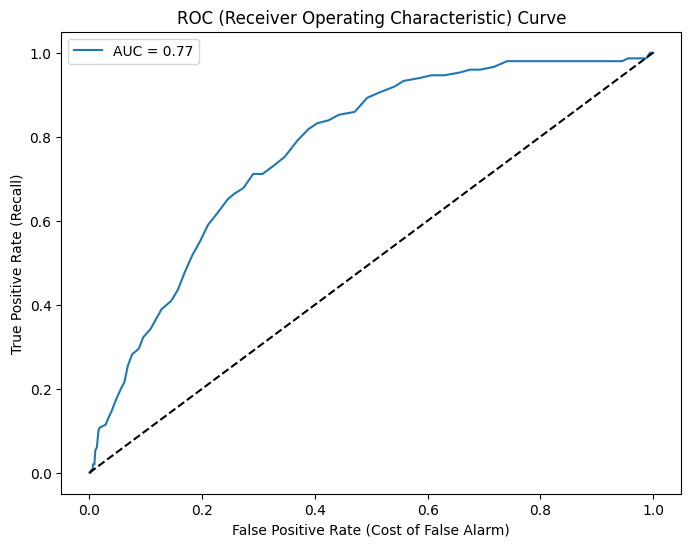

In [292]:
# Plot the ROC Curve
y_probs_K4 = knn_grid_K4_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_K4)
auc_K4 = round(roc_auc_score(y_test, y_probs_K4), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_K4):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [293]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_K4 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_K4 :.1f}')

The optimal threshold is 0.4


In [294]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_K4)
avg_precision = average_precision_score(y_test, y_probs_K4)

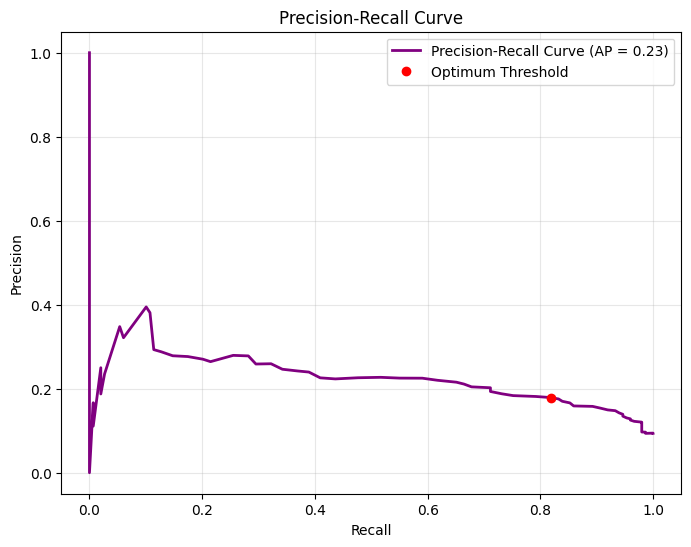

In [295]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_K4))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimum Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [296]:
# Evaluate precision and recall at different thresholds
y_probs_K4 = knn_grid_K4_opt.predict_proba(X_test)[:, 1]
thresholds = np.arange(0, 0.7, 0.05)
for threshold in thresholds:
    preds = (y_probs_K4 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.10 | Recall=0.99
Threshold=0.10 | Precision=0.10 | Recall=0.98
Threshold=0.15 | Precision=0.11 | Recall=0.98
Threshold=0.20 | Precision=0.11 | Recall=0.98
Threshold=0.25 | Precision=0.13 | Recall=0.96
Threshold=0.30 | Precision=0.14 | Recall=0.94
Threshold=0.35 | Precision=0.16 | Recall=0.89
Threshold=0.40 | Precision=0.17 | Recall=0.84
Threshold=0.45 | Precision=0.18 | Recall=0.75
Threshold=0.50 | Precision=0.20 | Recall=0.68
Threshold=0.55 | Precision=0.23 | Recall=0.59
Threshold=0.60 | Precision=0.23 | Recall=0.41
Threshold=0.65 | Precision=0.25 | Recall=0.34


In [297]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_K4 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.30000000000000004


In [298]:
# Define Model K4 threshold
threshold_K4 = best_threshold

In [299]:
# Use the threshold maximizing profits
y_pred_K4 = (y_probs_K4 >= best_threshold).astype(int)

In [300]:
# Generate classification report

print(classification_report(y_test, y_pred_K4))

              precision    recall  f1-score   support

           0       0.99      0.41      0.58      1439
           1       0.14      0.94      0.25       149

    accuracy                           0.46      1588
   macro avg       0.56      0.68      0.42      1588
weighted avg       0.91      0.46      0.55      1588



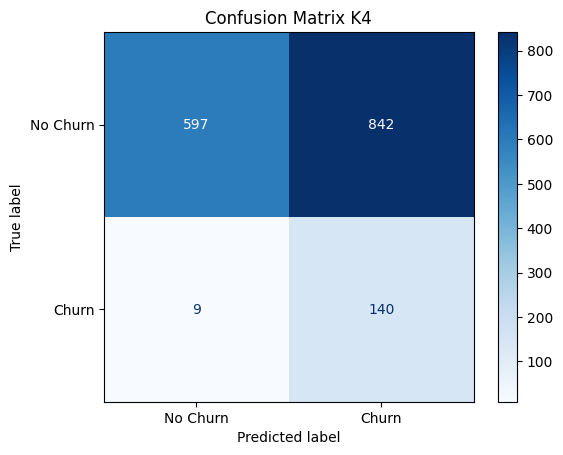

In [301]:
# Display confusion matrix
conf_matrix_K4 = confusion_matrix(y_test, y_pred_K4)
disp_K4 = ConfusionMatrixDisplay(conf_matrix_K4, display_labels=['No Churn','Churn'])
disp_K4.plot(cmap='Blues')
plt.title('Confusion Matrix K4')
plt.show()

In [302]:
# Values for false positive (fp_K4), false negative (fn_K4), true positive (tp_K4) and true negative (tn_K4)
fp_K4 = conf_matrix_K4[0][1]
fn_K4 = conf_matrix_K4[1][0]
tp_K4 = conf_matrix_K4[1][1]
tn_K4 = conf_matrix_K4[0][0]

print(f' fp_K4: {fp_K4} \n fn_K4: {fn_K4} \n tp_K4: {tp_K4} \n tn_K4: {tn_K4}')

 fp_K4: 842 
 fn_K4: 9 
 tp_K4: 140 
 tn_K4: 597


In [303]:
# Calculations for accuracy, precision, recall
accuracy_K4 = (tp_K4 + tn_K4)/len(y_test)
precision_K4 = tp_K4/(tp_K4 + fp_K4)
recall_K4 = tp_K4/(tp_K4 + fn_K4)

print(f'Accuracy_K4: {accuracy_K4:.2f}')
print(f'Precision_K4: {precision_K4:.2f}')
print(f'Recall_K4: {recall_K4:.2f}')
print(f'-'*18)

Accuracy_K4: 0.46
Precision_K4: 0.14
Recall_K4: 0.94
------------------


In [304]:
# Calculate F2 score for Model K4
beta = 2
F2_score_K4 = (1 + beta**2) * (precision_K4 * recall_K4) / (beta**2 * precision_K4 + recall_K4)

print(f'The F2 score for Model K4 is {F2_score_K4:.4f}')

The F2 score for Model K4 is 0.4436


In [305]:
# Profit/loss analysis
Profit_Loss_K4 = tp_K4*(L - C) - fp_K4*C - fn_K4*L

print(f'The profit or loss is ${Profit_Loss_K4}')

The profit or loss is $26220


**Feature Importance Model K4**      
The model finds the features **csat_score**, **payment_failures**, **weekly_active_days**, and **monthly_logins** to be highly important.


In [306]:
# Extract the selector from the pipeline
selector = knn_pipe_K4.named_steps["select"]

In [307]:
# Access the Random Forest model for the importances
rf_model = selector.estimator_
importances = rf_model.feature_importances_

In [308]:
# Get feature names from the preprocessor
feature_names = knn_pipe_K4.named_steps["preprocessor"].get_feature_names_out()

In [309]:
# Get only selected features
mask = selector.get_support()
selected_features = feature_names[mask]
selected_importances = importances[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names

print(f'There are {len(selected_features)} selected features.')

There are 18 selected features.


In [310]:
# Build features importance dataframe
K4_feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": selected_importances
}).sort_values(by="importance", ascending=False)

# Reset index
K4_feature_importance_df = K4_feature_importance_df.reset_index(drop=True)
K4_feature_importance_df.index = K4_feature_importance_df.index + 1
K4_feature_importance_df.index.name = "Rank"

K4_feature_importance_df.head(10)

,feature,importance
Rank,,
1,csat_score,0.130414
2,tenure_months,0.063662
3,payment_method_Card,0.051512
4,payment_failures,0.046569
5,monthly_logins,0.042920
6,tenure_fee_interaction,0.035794
7,payment_method_PayPal,0.031936
8,complaint_type_Technical,0.021571
9,country_Bangladesh,0.020772


In [311]:
# Select the first twenty features
K4_feature_importance_df = K4_feature_importance_df.iloc[:20]

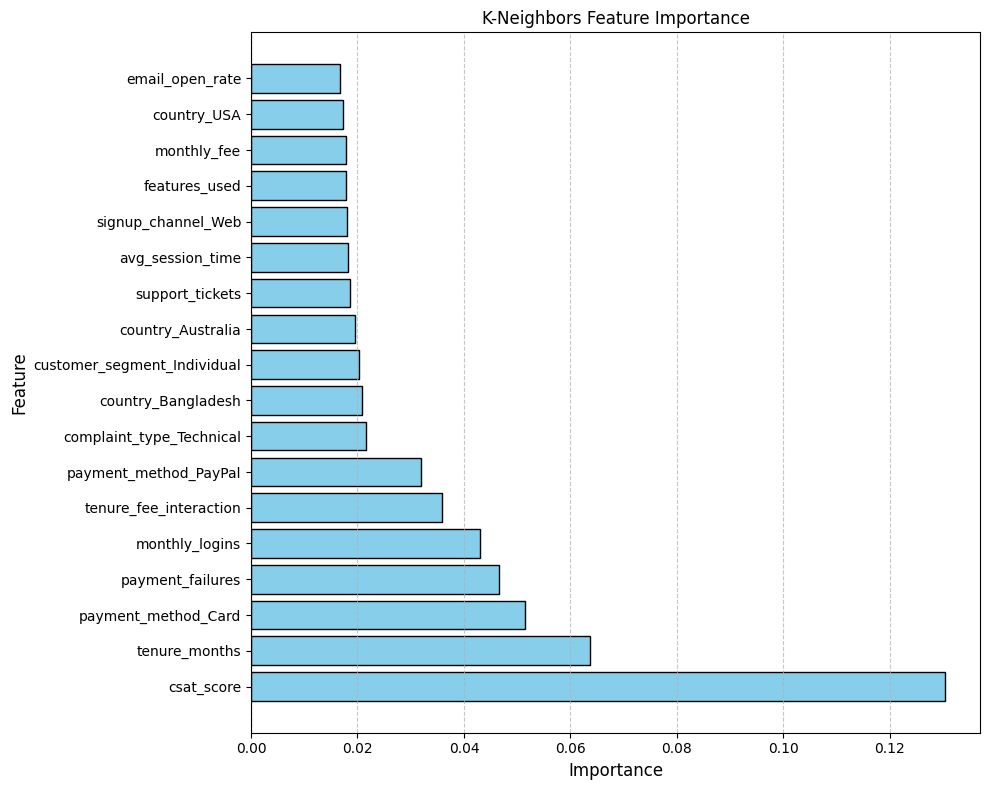

In [312]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in K4_feature_importance_df['importance']]
plt.barh(K4_feature_importance_df['feature'], K4_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('K-Neighbors Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different KNeighbors models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.   

In [313]:
# Build a comparison dataframe
knn_models_df = pd.DataFrame({
    'K-Neighbors Classifier': ['Model K2','Model K3','Model K4'],
    'AUC': [auc_K2, auc_K3, auc_K4],
    'Accuracy': [accuracy_K2, accuracy_K3, accuracy_K4],
    'Precision': [precision_K2, precision_K3, precision_K4],
    'Recall': [recall_K2, recall_K3, recall_K4],
    'F2 Score': [F2_score_K2, F2_score_K3, F2_score_K4],
    'Profit/Loss': [Profit_Loss_K2, Profit_Loss_K3, Profit_Loss_K4],
})
knn_models_df

,K-Neighbors Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model K2,0.691,0.326196,0.116570,0.939597,0.389538,17460
1,Model K3,0.741,0.377204,0.125668,0.946309,0.410361,21620
2,Model K4,0.770,0.464106,0.142566,0.939597,0.443599,26220


In [314]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC','Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
    fig.add_trace(
        go.Scatter(
          x=knn_models_df['K-Neighbors Classifier'],
          y=knn_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=knn_models_df['K-Neighbors Classifier'],
          y=knn_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
       )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='K-Neighbors Classifier'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [315]:
# Output the best KNeighbors model performance metrics based on profit/loss
knn_metrics_df = knn_models_df.loc[[knn_models_df["Profit/Loss"].idxmax()]]

knn_metrics_df.to_csv("knn_metrics.csv", index=False)

knn_metrics_df.head()

,K-Neighbors Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
2,Model K4,0.77,0.464106,0.142566,0.939597,0.443599,26220


In [316]:
# Output the first eight (8) features importance
model = knn_metrics_df.iloc[0, 0]

if model == 'Model K2':
  print(K2_feature_importance_df.head(8), '\n')
  K2_feature_importance_df.to_csv("knn_features.csv", index=False)
elif model == 'Model K3':
  print(K3_feature_importance_df.head(8), '\n')
  K3_feature_importance_df.to_csv("knn_features.csv", index=False)
else:
  print(K4_feature_importance_df.head(8), '\n')
  K4_feature_importance_df.to_csv("knn_features.csv", index=False)

print(f'The best model is {model}.')

                       feature  importance
Rank                                      
1                   csat_score    0.130414
2                tenure_months    0.063662
3          payment_method_Card    0.051512
4             payment_failures    0.046569
5               monthly_logins    0.042920
6       tenure_fee_interaction    0.035794
7        payment_method_PayPal    0.031936
8     complaint_type_Technical    0.021571 

The best model is Model K4.


**Sample Predictions**   

In [317]:
# Establish best model
model = knn_metrics_df.iloc[0, 0]

if model == 'Model K2':
  model_opt = knn_pipe2_opt
  best_threshold = threshold_K2
elif model == 'Model K3':
  model_opt = knn_grid_K3_opt
  best_threshold = threshold_K3
else:
  model_opt = knn_grid_K4_opt
  best_threshold = threshold_K4

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model K4 and the best threshold is 0.30000000000000004.


**Sample 1**     


In [318]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [319]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [320]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = model_opt.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.64


**Sample 2**     


In [321]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [322]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [323]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = model_opt.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.33


**Sample 3**    


In [324]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [325]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [326]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = model_opt.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.42


**Sample 4**     


In [327]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [328]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [329]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = model_opt.predict_proba(pd.DataFrame([sample4]))[:, 1][0]

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.35


**Sample 5**    


In [330]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [331]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [332]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = model_opt.predict_proba(pd.DataFrame([sample5]))[:, 1][0]

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.55
